In [11]:
# Import robot_python_code.py
from robot_python_code import DataLoader
from parameters import trial_time

trial_time_1 = 7500
steer_angle_and_yaw_1 = [
    [+20, 180],
    [+20, 183],
    [-20, 180 + 47.5],
    [-20, 180 + 45],

    [15, 180 + 50],
    [15, 180 + 45],
    [-15, 170],
    [-15, 162],

    [+10, 180 + 90 + 15],
    [+10, 180 + 90 + 17],
    [-10, 90 + 26],
    [-10, 90 + 23],

    [+5, 180 + 90 + 64],
    [+5, 180 + 90 + 70],
    [-5, 62],
    [-5, 55],

    [0, 270 + 85],
    [0, 270 + 84],
]

trial_time_2 = 5000
steer_angle_and_yaw_2 = [
    [+20, 180 + 65],
    [+20, 180 + 60],
    [-20, 155],
    [-20, 157.5],

    [+15, 180 + 93],
    [+15, 180 + 95],
    [-15, 115],
    [-15, 115],

    [+10, 180 + 127.5],
    [+10, 180 + 90 + 41],
    [-10, 77],
    [-10, 78],

    [+5, 180 + 165],
    [+5, 180 + 165],
    [-5, 40],
    [-5, 42],

    [0, 360 - 5],
    [0, 360 - 7],
]

trial_time_3 = 15000
steer_angle_and_yaw_3 = [
    [+20, 3],
    [+20, 5],
    [-20, 360 + 105],
    [-20, 360 + 103],

    [+15, 91],
    [+15, 93],
    [-15, 180 + 90 + 77],
    [-15, 180 + 90 + 75], 

    [+10, 180 + 30],
    [+10, 180 + 30],
    [-10, 180 + 47], 
    [-10, 180 + 50], 

    [+5, 180 + 90 + 40],
    [+5, 180 + 90 + 38],
    [-5, 90 + 43],
    [-5, 130]
]

In [12]:
trial_data = []

for steer_angle, yaw in steer_angle_and_yaw_1:
    if steer_angle >= 0:
        yaw =  (360 - yaw)

    yaw_rate = yaw / trial_time_1

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

for steer_angle, yaw in steer_angle_and_yaw_2:
    if steer_angle >= 0:
        yaw =  (360 - yaw)    

    yaw_rate = yaw / trial_time_2   

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

for steer_angle, yaw in steer_angle_and_yaw_3:
    if steer_angle >= 0:
        yaw =  (360 - yaw)

    yaw_rate = yaw / trial_time_3

    trial_data.append({'yaw_rate': yaw_rate, 'steer_angle': steer_angle})

# Sort by steering angle
trial_data = sorted(trial_data, key=lambda x: x['steer_angle'])

# print(*trial_data, sep='\n')

In [13]:
import matplotlib.pyplot as plt

x_data = [trial['steer_angle'] for trial in trial_data]
y_data = [trial['yaw_rate'] for trial in trial_data]

print(x_data)
print(y_data)

# plt.xlabel(f'Encoder Count $e$')
# plt.ylabel(f'Distance $s$ (meters)')
# plt.title('Distance Traveled vs Encoder Count')

# plt.plot(x_data, y_data, marker='o')

[-20, -20, -20, -20, -20, -20, -15, -15, -15, -15, -15, -15, -10, -10, -10, -10, -10, -10, -5, -5, -5, -5, -5, -5, 0, 0, 0, 0, 5, 5, 5, 5, 5, 5, 10, 10, 10, 10, 10, 10, 15, 15, 15, 15, 15, 15, 20, 20, 20, 20, 20, 20]
[0.030333333333333334, 0.03, 0.031, 0.0315, 0.031, 0.030866666666666667, 0.02266666666666667, 0.0216, 0.023, 0.023, 0.023133333333333332, 0.023, 0.015466666666666667, 0.015066666666666667, 0.0154, 0.0156, 0.015133333333333334, 0.015333333333333332, 0.008266666666666667, 0.007333333333333333, 0.008, 0.0084, 0.008866666666666667, 0.008666666666666666, 0.0006666666666666666, 0.0008, 0.001, 0.0014, 0.0034666666666666665, 0.0026666666666666666, 0.003, 0.003, 0.0033333333333333335, 0.0034666666666666665, 0.01, 0.009733333333333333, 0.0105, 0.0098, 0.01, 0.01, 0.017333333333333333, 0.018, 0.0174, 0.017, 0.017933333333333332, 0.0178, 0.024, 0.0236, 0.023, 0.024, 0.0238, 0.023666666666666666]


Coefficients: [ 0.00503049 -0.0039763   0.02361841]
Fitted Polynomial: ω = 5.030494e-03 * α^2 + -3.976296e-03 * α + 2.361841e-02


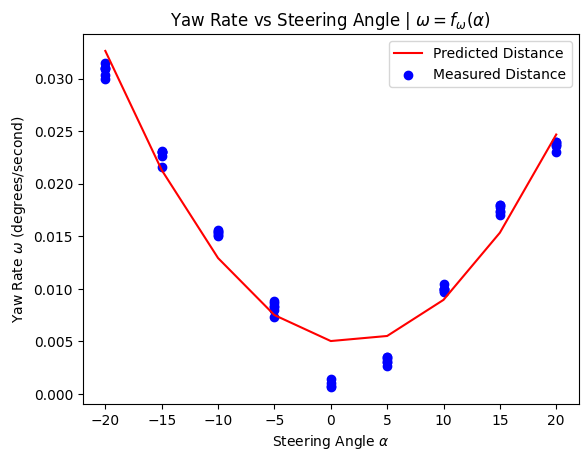

In [14]:
import numpy as np
from numpy.polynomial import Polynomial

x_data = np.array(x_data, dtype=np.float64)
y_data = np.array(y_data, dtype=np.float64)

p = Polynomial.fit(x_data, y_data, deg=2)
y_pre = p(x_data)

print("Coefficients:", p.coef)
print(f"Fitted Polynomial: ω = {p.coef[0]:.6e} * α^2 + {p.coef[1]:.6e} * α + {p.coef[2]:.6e}")

plt.plot(x_data, y_pre, label='Predicted Distance', color='red')
plt.scatter(x_data, y_data, label='Measured Distance', color='blue')
plt.legend()

plt.xlabel(f'Steering Angle $\\alpha$')
plt.ylabel(f'Yaw Rate $\\omega$ (degrees/second)')
plt.title(f'Yaw Rate vs Steering Angle | $\\omega = f_{{\\omega}}(\\alpha)$')

plt.show()


In [15]:
#  Standard deviation of errors
sigma2 = (y_data - y_pre) ** 2

print(sigma2)

# plt.plot(x_data, sigma2, marker='o')
# plt.xlabel(f'Encoder Count $e$')
# plt.ylabel(f'Error Variance $\sigma_s^2$')
# plt.title('Error Variance vs Encoder Count')
# plt.show()

[5.25267060e-06 6.89169541e-06 2.64128765e-06 1.26608377e-06
 2.64128765e-06 3.09245313e-06 1.87304600e-06 9.11593353e-08
 2.89655226e-06 2.89655226e-06 3.36817698e-06 2.89655226e-06
 6.46899018e-06 4.59425341e-06 6.13431183e-06 7.16501355e-06
 4.88448732e-06 5.80852237e-06 5.86675635e-07 2.80180036e-08
 2.49281391e-07 8.08706090e-07 1.86581268e-06 1.35943367e-06
 1.90429909e-05 1.78970813e-05 1.62448836e-05 1.31804883e-05
 4.18572445e-06 8.09917135e-06 6.31301292e-06 6.31301292e-06
 4.74907671e-06 4.18572445e-06 1.10891555e-06 6.18399675e-07
 2.41196614e-06 7.27695309e-07 1.10891555e-06 1.10891555e-06
 3.99881537e-06 7.10953158e-06 4.26988699e-06 2.77679060e-06
 6.75845995e-06 6.08298338e-06 4.52405943e-07 1.15049497e-06
 2.79762852e-06 4.52405943e-07 7.61450457e-07 1.01192458e-06]


Error Coefficients: [ 6.06057171e-06 -4.07857014e-07 -4.19866455e-06]
Fitted Polynomial for Error Variance: σ² = 6.060572e-06 * α^2 + -4.078570e-07 * α + -4.198665e-06


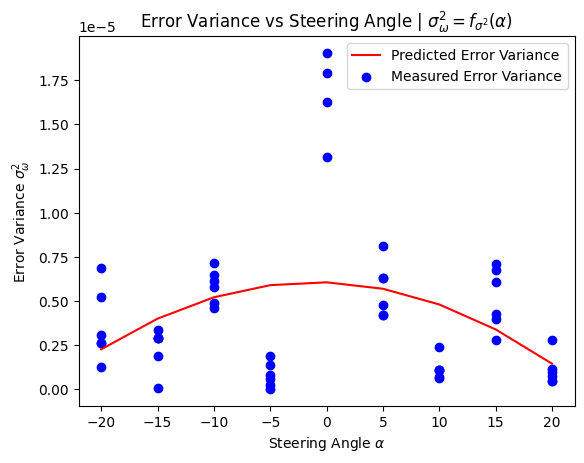

In [17]:
p = Polynomial.fit(x_data, sigma2, deg=2)
print("Error Coefficients:", p.coef)
print(f"Fitted Polynomial for Error Variance: σ² = {p.coef[0]:.6e} * α^2 + {p.coef[1]:.6e} * α + {p.coef[2]:.6e}")
y_fit = p(x_data)

plt.plot(x_data, y_fit, label='Predicted Error Variance', color='red')
plt.scatter(x_data, sigma2, marker='o', label='Measured Error Variance', color='blue')
plt.xlabel(f'Steering Angle $\\alpha$')
plt.ylabel(f'Error Variance $\\sigma_{{\\omega}}^2$')
plt.title(f'Error Variance vs Steering Angle | $\\sigma_{{\\omega}}^2 = f_{{\\sigma^2}}(\\alpha)$')
plt.legend()
plt.show()
